In [6]:
from typing import Literal, TypedDict

class PortfolioState(TypedDict):
    amt_usd: float
    total_usd: float
    target_currency: Literal['USD', 'EUR', 'JPY']
    total_target_currency: float

def calc_total(state:PortfolioState)->PortfolioState:
    state['total_usd'] = state['amt_usd'] * 1.80
    return state

def convert_to_inr(state:PortfolioState)->PortfolioState:
    state['total_target_currency']= state['total_usd'] * 86.0
    return state

def convert_to_eur(state:PortfolioState)->PortfolioState:
    state['total_target_currency']= state['total_usd'] * 0.9
    return state

def convert_to_jpy(state:PortfolioState)->PortfolioState:
    state['total_target_currency']= state['total_usd'] * 110.0
    return state

def choose_currency(state:PortfolioState)->str:
    return state['target_currency']

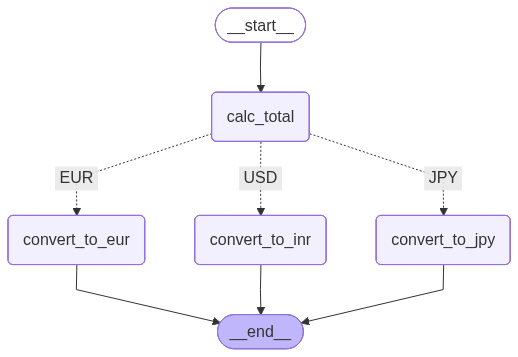

In [7]:
from langgraph.graph import START,END, StateGraph

builder = StateGraph(PortfolioState)

builder.add_node("calc_total", calc_total)
builder.add_node("convert_to_inr", convert_to_inr)
builder.add_node("convert_to_eur", convert_to_eur)
builder.add_node("convert_to_jpy", convert_to_jpy)

builder.add_edge(START, "calc_total")
builder.add_conditional_edges(
    "calc_total",
    choose_currency,
    {
        "USD": "convert_to_inr",
        "EUR": "convert_to_eur",
        "JPY": "convert_to_jpy"
    }
)

builder.add_edge(["convert_to_inr", "convert_to_eur", "convert_to_jpy"], END)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke({"amt_usd": 1000.00, "target_currency": "EUR"})

{'amt_usd': 1000.0,
 'total_usd': 1800.0,
 'target_currency': 'EUR',
 'total_target_currency': 1620.0}